In [ ]:
# ==============================
# INSTALLS
# ==============================
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [ ]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import evaluate

print("GPU Available:", torch.cuda.is_available())

GPU Available: False


In [ ]:
# ==============================
# LOAD FUNCTION
# ==============================
def load_dataset(file_path):
    try:
        if file_path.endswith(".csv"):
            return pd.read_csv(file_path, low_memory=False)
        elif file_path.endswith(".jsonl"):
            return pd.read_json(file_path, lines=True)
        elif file_path.endswith(".json"):
            return pd.read_json(file_path)
        elif file_path.endswith(".xlsx"):
            return pd.read_excel(file_path)
        else:
            return None
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

In [ ]:
# ==============================
# NORMALIZATION FUNCTION
# ==============================
def normalize_columns(df):
    df = df.copy()

    text_cols = ["text", "email_text", "content", "body", "message"]
    subject_cols = ["subject", "title"]

    subject = ""
    body = ""

    for col in subject_cols:
        if col in df.columns:
            subject = df[col].astype(str).fillna("")
            break

    for col in text_cols:
        if col in df.columns:
            body = df[col].astype(str).fillna("")
            break

    df["text"] = subject + " " + body

    possible_label_cols = ["label", "class", "is_phishing", "target", "spam", "category"]

    label_col = None
    for col in possible_label_cols:
        if col in df.columns:
            label_col = col
            break

    if label_col is None:
        return None

    def map_label(val):
        if isinstance(val, str):
            val = val.lower().strip()
            if val in ["phishing", "spam", "scam", "malicious"]:
                return 1
            if val in ["benign", "legitimate", "ham", "safe"]:
                return 0
            return None
        else:
            if val in [1, "1"]:
                return 1
            if val in [0, "0"]:
                return 0
            return None

    df["label"] = df[label_col].apply(map_label)
    df = df[["text", "label"]].dropna()
    df["label"] = df["label"].astype(int)

    return df

In [ ]:
# ==============================
# DATA FILES
# ==============================
dataset_files = [
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/spamResults.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/phishing and benign email dataset.jsonl",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/enron_spam_data.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/email.xlsx",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/SpamAssasin.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Phishing_validation_emails.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/PhishingEmailDataset_1.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Nigerian_Fraud.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Nazario.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Ling.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Enron1.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Enron.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Email_scam.csv",
    "/content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/CEAS_08.csv"
]

In [ ]:
# ==============================
# LOAD + MERGE DATA
# ==============================
dfs = []

for file in dataset_files:
    print(f"Processing: {file}")
    df = load_dataset(file)
    if df is None:
        continue

    df = normalize_columns(df)
    if df is not None and len(df) > 0:
        dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

print("Original dataset size:", len(final_df))

Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/spamResults.csv
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/phishing and benign email dataset.jsonl
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/enron_spam_data.csv
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/email.xlsx
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/SpamAssasin.csv
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Phishing_validation_emails.csv
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/PhishingEmailDataset_1.csv
Error loading /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/PhishingEmailDataset_1.csv: 'utf-8' codec can't decode byte 0xca in position 1076: invalid continuation byte
Processing: /content/drive/MyDrive/Email_Datasets_for_fyp/FinalDatasetForEmail/Nigerian_Fraud.cs

In [ ]:
# ==============================
# LIMIT DATASET
# ==============================
MAX_SAMPLES = 10000

if len(final_df) > MAX_SAMPLES:
    final_df = final_df.sample(MAX_SAMPLES, random_state=42)

print("Using dataset size:", len(final_df))
print(final_df["label"].value_counts())

Using dataset size: 10000
label
1    5322
0    4678
Name: count, dtype: int64


In [ ]:
# ==============================
# SPLIT DATA
# ==============================
train_df, test_df = train_test_split(
    final_df,
    test_size=0.2,
    stratify=final_df["label"],
    random_state=42
)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
# ==============================
# TOKENIZER
# ==============================
model_name = "prajjwal1/bert-tiny"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format(type='torch')
test_dataset.set_format(type='torch')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# ==============================
# MODEL
# ==============================
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

In [ ]:
# ==============================
# METRICS
# ==============================
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return metric.compute(predictions=preds, references=labels)

In [ ]:
# ==============================
# TRAINING ARGS
# ==============================
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Email_Datasets_for_fyp",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    logging_steps=200,
    save_total_limit=2,
    report_to="none"
)

In [ ]:
# ==============================
# TRAINER
# ==============================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# ==============================
# TRAIN
# ==============================
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
200,0.673857
400,0.613842
600,0.539644
800,0.454754
1000,0.417428
1200,0.346251
1400,0.306459
1600,0.295837
1800,0.294187
2000,0.265679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2000, training_loss=0.4207937870025635, metrics={'train_runtime': 137.0378, 'train_samples_per_second': 58.378, 'train_steps_per_second': 14.595, 'total_flos': 1270487040000.0, 'train_loss': 0.4207937870025635, 'epoch': 1.0})

In [ ]:
# ==============================
# EVALUATE
# ==============================
results = trainer.evaluate()
print("Accuracy:", results["eval_accuracy"])

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.9055


In [ ]:
# ==============================
# SAVE MODEL
# ==============================
save_path = "/content/drive/MyDrive/Email_Datasets_for_fyp"
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("Model saved at:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved at: /content/drive/MyDrive/Email_Datasets_for_fyp


In [ ]:
def predict_email(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs).item()

    return "Phishing" if pred == 1 else "Legitimate"

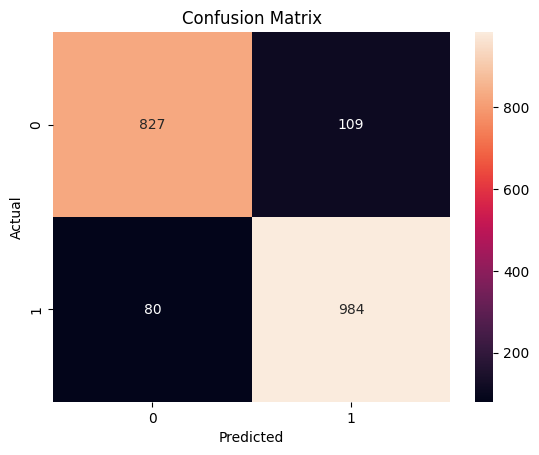

              precision    recall  f1-score   support

           0       0.91      0.88      0.90       936
           1       0.90      0.92      0.91      1064

    accuracy                           0.91      2000
   macro avg       0.91      0.90      0.90      2000
weighted avg       0.91      0.91      0.91      2000



In [ ]:
model.eval()
y_true = []
y_pred = []

for batch in test_dataset:
    inputs = {k: batch[k].unsqueeze(0) for k in ["input_ids", "attention_mask"]}
    labels = batch["label"].item()
    with torch.no_grad():
        outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=-1).item()

    y_true.append(labels)
    y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))

In [ ]:
email_text = """

Dear Students,

As we approach the final stages of your Final Year Project, please be advised that the Pre-Defense sessions are scheduled to begin shortly. This is a critical phase of your evaluation. To ensure you are eligible and fully prepared, all student groups must adhere to the following directives immediately:

1. Mandatory Physical Meetings
You are required to attend a compulsory in-person meeting with your supervisor next week. This meeting is strictly physical; online sessions will not be permitted. During this time, your supervisor will outline the specific requirements and expectations for your upcoming pre-defense.

2. Pre-Defense Requirements & Verification
Before your scheduled defense, you must ensure the following are completed:

Work Verification: Review and verify all technical work and documentation completed to date. Ensure your project meets the departmental standards discussed with your mentor.

Log Sheets: Ensure your project log sheets are fully updated and signed by your supervisor. These serve as official proof of your project's evolution.

Attendance Records: Confirm that your attendance for all scheduled lab sessions and meetings has been accurately marked.

Note: Failure to maintain updated log sheets or missing the mandatory meeting next week may result in disqualification from the upcoming pre-defense.

Please coordinate with your group members and supervisors immediately to finalize your meeting time.
"""

print(predict_email(email_text))

Legitimate
